In [ ]:
rafrom google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install scikit-learn pandas


###########################

Balancing the dataset


In [ ]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Final Year Project/blackhole.csv')

# Separate features and target
X = df.drop(columns=['label'])
y = df['label']

# Option 1: Oversampling the minority class
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Option 2: Undersampling the majority class
# undersampler = RandomUnderSampler(random_state=42)
# X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Combine resampled features and target into a new DataFrame
df_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='label')], axis=1)

# Check the distribution of the label after resampling
print(df_resampled['label'].value_counts())

# Save the balanced dataset to a new CSV file
df_resampled.to_csv('/content/drive/MyDrive/Final Year Project/balanced_blackhole.csv', index=False)


label
0    269852
1    269852
Name: count, dtype: int64


In [ ]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/Final Year Project/balanced_blackhole.csv')
data

,time,source,destination,length,info,transmission_rate_per_1000_ms,reception_rate_per_1000_ms,transmission_average_per_sec,reception_average_per_sec,transmission_count_per_sec,reception_count_per_sec,transmission_total_duration_per_sec,reception_total_duration_per_sec,dao,dis,dio,category,label
0,0.037,39,9999,0.000000,1.000000,0.000000,0.671176,0.000000,0.499879,0.000000,0.671176,0.539313,0.570032,0.0,0.0,0.000000,Normal,0
1,0.037,39,9999,0.000000,1.000000,0.000000,0.649873,0.000000,0.505234,0.000000,0.649873,0.264704,0.530547,0.0,0.0,0.000000,Normal,0
2,0.038,39,9999,0.000000,1.000000,0.671176,0.652361,0.462516,0.501327,0.671768,0.652361,0.546376,1.000000,0.0,0.0,0.690115,Blackhole,1
3,0.045,39,9999,0.000000,1.000000,0.000000,0.633786,0.000000,0.517346,0.000000,0.634105,0.585425,0.553276,0.0,0.0,0.000000,Normal,0
4,0.046,39,9999,0.000000,1.000000,0.000000,0.630378,0.000000,0.538789,0.000000,0.630378,0.443171,0.615377,0.0,0.0,0.000000,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539699,555.847,91,2,0.485467,0.000000,0.469580,0.606685,0.554688,0.492306,0.469960,0.607132,0.435817,0.496621,0.0,0.0,0.000000,Blackhole,1
539700,435.772,93,15,0.485467,0.000000,0.520668,0.000000,0.535023,0.000000,0.520915,0.000000,0.498552,0.535797,0.0,0.0,0.000000,Blackhole,1
539701,530.338,69,96,0.485467,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.554547,0.412039,0.0,0.0,0.000000,Blackhole,1
539702,170.155,50,73,0.485955,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.352126,0.580352,0.0,0.0,0.000000,Blackhole,1


In [ ]:
zero_count = data['label'].value_counts()[0]
one_count = data['label'].value_counts()[1]

print(f"Number of zeros: {zero_count}")
print(f"Number of ones: {one_count}")

Number of zeros: 269852
Number of ones: 269852


# Ensemble learning

Accuracy: 91.39%
Precision: 85.27%
Recall: 100.00%
F1 Score: 92.05%


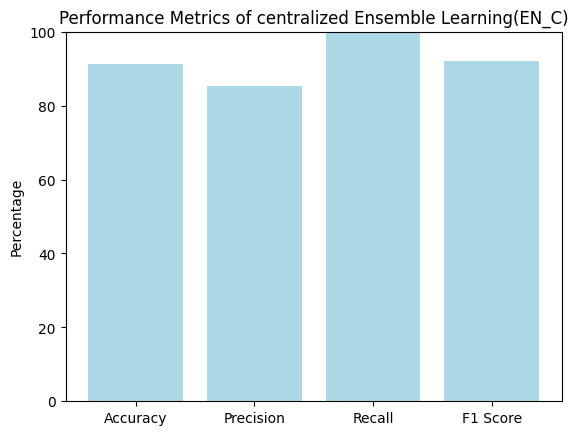

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler

# Load the dataset
# data = pd.read_csv('your_dataset.csv')  # Replace with your dataset path

# Data preprocessing
X = data.drop(columns=['category','label'])  # Replace 'category' and 'label' with appropriate column names
y = data['label']  # Replace 'label' with your target variable name

# Handling missing values in features and target
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y = np.array(y).reshape(-1, 1)
y = imputer.fit_transform(y).ravel()  # Impute missing values in target

# Convert target to integers if needed
y = y.astype(int)

# Balancing the dataset using RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize models
rf_model = RandomForestClassifier()
gb_model = GradientBoostingClassifier()

# Fit models on the training data
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Predict probabilities for both models
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_prob_gb = gb_model.predict_proba(X_test)[:, 1]

# Combine predictions using averaging
y_pred_ensemble = (y_pred_prob_rf + y_pred_prob_gb) / 2

# Threshold the combined prediction to classify
y_pred_final = (y_pred_ensemble > 0.10).astype(int)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

# Print results
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Plotting the results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy * 100, precision * 100, recall * 100, f1 * 100]

plt.bar(metrics, scores, color='lightblue')
plt.ylim(0, 100)
plt.title('Performance Metrics of centralized Ensemble Learning(EN_C)')
plt.ylabel('Percentage')
plt.show()


##  Tradition ensemble(Random forest + Gradient Boosing) federated


**Ensemble Horizontal federated learning**

Accuracy: 0.9332
Precision: 0.8821
Recall: 1.0000
F1 Score: 0.9374


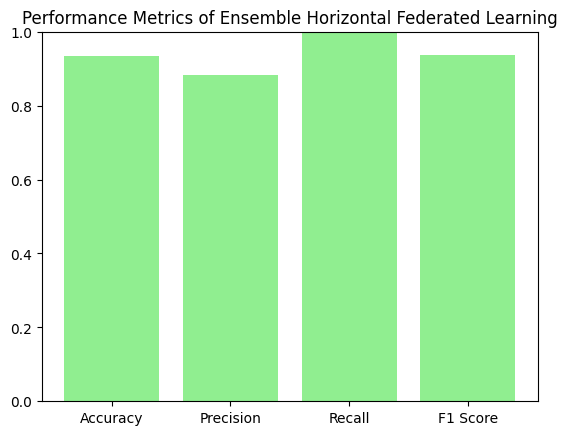

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Load the dataset
#data = pd.read_csv('/content/drive/MyDrive/Final Year Project/blackhole.csv')

# Data preprocessing
X = data.drop(columns=['category','label'])  # Features
y = data['label']  # Target variable

# Handling missing values in features and target
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y = np.array(y).reshape(-1, 1)
y = imputer.fit_transform(y).ravel()  # Impute missing values in target

# Convert target to integers
y = y.astype(int)

# Splitting data into federated clients (simulating 2 clients)
X1, X2, y1, y2 = train_test_split(X, y, test_size=0.3, random_state=42)  # Adjust test_size

# Standardize the data
scaler = StandardScaler()
X1 = scaler.fit_transform(X1)
X2 = scaler.transform(X2)  # Ensure using the same scaler

# Initialize models
rf_model1 = RandomForestClassifier()
gb_model1 = GradientBoostingClassifier()

rf_model2 = RandomForestClassifier()
gb_model2 = GradientBoostingClassifier()

# Fit models on each client's data
rf_model1.fit(X1, y1)
gb_model1.fit(X1, y1)

rf_model2.fit(X2, y2)
gb_model2.fit(X2, y2)

# Predict probabilities for models
y_pred_prob_rf1 = rf_model1.predict_proba(X1)[:, 1]
y_pred_prob_gb1 = gb_model1.predict_proba(X1)[:, 1]

y_pred_prob_rf2 = rf_model2.predict_proba(X2)[:, 1]
y_pred_prob_gb2 = gb_model2.predict_proba(X2)[:, 1]

# Combine predictions using averaging
y_pred_ensemble1 = (y_pred_prob_rf1 + y_pred_prob_gb1) / 2
y_pred_ensemble2 = (y_pred_prob_rf2 + y_pred_prob_gb2) / 2

# Threshold the combined prediction to classify
y_pred_final1 = (y_pred_ensemble1 > 0.1).astype(int)  # Adjust threshold if needed
y_pred_final2 = (y_pred_ensemble2 > 0.2).astype(int)  # Adjust threshold if needed

# Combine predictions and ground truth from both clients
y_true_combined = np.concatenate([y1, y2])
y_pred_combined = np.concatenate([y_pred_final1, y_pred_final2])

# Calculate performance metrics
accuracy = accuracy_score(y_true_combined, y_pred_combined)
precision = precision_score(y_true_combined, y_pred_combined)
recall = recall_score(y_true_combined, y_pred_combined)
f1 = f1_score(y_true_combined, y_pred_combined)

# Print results
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plotting the results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.bar(metrics, scores, color='lightgreen')
plt.ylim(0, 1)
plt.title('Performance Metrics of Ensemble Horizontal Federated Learning')
plt.show()


**Ensemble vertical federated learning**

Accuracy: 0.9456
Precision: 0.9082
Recall: 0.9914
F1 Score: 0.9480


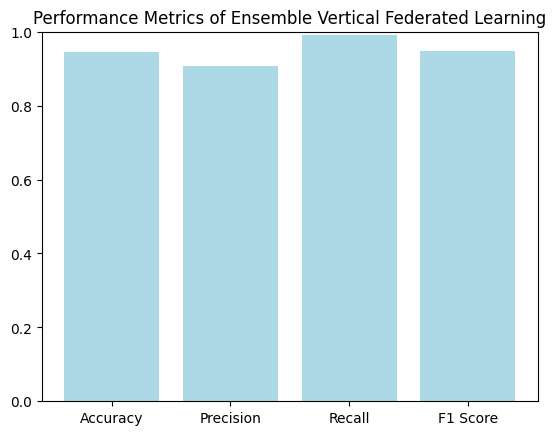

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Load the dataset
#data = pd.read_csv('/content/drive/MyDrive/Final Year Project/blackhole.csv')

# Data preprocessing
X = data.drop(columns=['category', 'label'])  # Features
y = data['label']  # Target variable

# Handling missing values in features and target
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y = np.array(y).reshape(-1, 1)
y = imputer.fit_transform(y).ravel()  # Impute missing values in target

# Convert target to integers
y = y.astype(int)

# Splitting data vertically into federated clients (simulating 2 clients)
# Here we split the features between clients, each getting different features
split_point = X.shape[1] // 2
X1 = X[:, :split_point]
X2 = X[:, split_point:]

# Standardize the data
scaler1 = StandardScaler()
X1 = scaler1.fit_transform(X1)

scaler2 = StandardScaler()
X2 = scaler2.fit_transform(X2)

# Train models on different parts of the dataset (Client 1: X1, Client 2: X2)
rf_model1 = RandomForestClassifier(random_state=42, n_estimators=46, max_depth=8, min_samples_split=33)
rf_model2 = RandomForestClassifier(random_state=42, n_estimators=46, max_depth=8, min_samples_split=33 )

rf_model1.fit(X1, y)
rf_model2.fit(X2, y)

gb_model1 = GradientBoostingClassifier( n_estimators=100,
    learning_rate=0.2,
    max_depth=5,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    subsample=1.0,
    random_state=42)
gb_model2 = GradientBoostingClassifier( n_estimators=100,
    learning_rate=0.2,
    max_depth=5,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    subsample=1.0,
    random_state=42)

gb_model1.fit(X1, y)
gb_model2.fit(X2, y)

# Predict probabilities for each model
y_pred_prob_rf1 = rf_model1.predict_proba(X1)[:, 1]
y_pred_prob_gb1 = gb_model1.predict_proba(X1)[:, 1]

y_pred_prob_rf2 = rf_model2.predict_proba(X2)[:, 1]
y_pred_prob_gb2 = gb_model2.predict_proba(X2)[:, 1]

# Combine predictions using averaging
y_pred_ensemble1 = (y_pred_prob_rf1 + y_pred_prob_gb1) / 2
y_pred_ensemble2 = (y_pred_prob_rf2 + y_pred_prob_gb2) / 2

# Combine vertical predictions
y_pred_final = (y_pred_ensemble1 + y_pred_ensemble2) / 2

# Threshold the combined prediction to classify
y_pred_final = (y_pred_final > 0.4).astype(int)  # Adjust threshold if needed

# Calculate performance metrics
accuracy = accuracy_score(y, y_pred_final)
precision = precision_score(y, y_pred_final)
recall = recall_score(y, y_pred_final)
f1 = f1_score(y, y_pred_final)

# Print results
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plotting the results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.bar(metrics, scores, color='lightblue')
plt.ylim(0, 1)
plt.title('Performance Metrics of Ensemble Vertical Federated Learning')
plt.show()


**Ensemble hybrid federated learning**

Accuracy: 0.9611
Precision: 0.9547
Recall: 0.9678
F1 Score: 0.9612


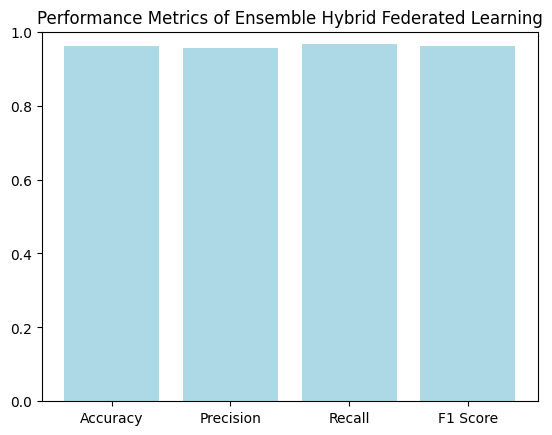

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Load the dataset
#data = pd.read_csv('/content/drive/MyDrive/Final Year Project/blackhole.csv')

# Data preprocessing
X = data.drop(columns=['category', 'label'])  # Features
y = data['label']  # Target variable

# Handling missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y = np.array(y).reshape(-1, 1)
y = imputer.fit_transform(y).ravel()  # Impute missing values in target

# Convert target to integers
y = y.astype(int)

# Split data for hybrid federated learning
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Further split training data into two parts for horizontal split
X_train1, X_train2, y_train1, y_train2 = train_test_split(X_train_full, y_train_full, test_size=0.5, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train1)
X_train2 = scaler.transform(X_train2)
X_test = scaler.transform(X_test)

# Initialize models for horizontal clients
rf_model1 = RandomForestClassifier(random_state=42, n_estimators=46, max_depth=8, min_samples_split=33)
gb_model1 = GradientBoostingClassifier( n_estimators=30,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    subsample=1.0,
    random_state=42)

rf_model2 = RandomForestClassifier(random_state=42, n_estimators=46, max_depth=8, min_samples_split=33)
gb_model2 = GradientBoostingClassifier( n_estimators=100,
    learning_rate=0.2,
    max_depth=5,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    subsample=1.0,
    random_state=42)

# Fit models on each client's data
rf_model1.fit(X_train1, y_train1)
gb_model1.fit(X_train1, y_train1)

rf_model2.fit(X_train2, y_train2)
gb_model2.fit(X_train2, y_train2)

# Predict probabilities for horizontal models
y_pred_prob_rf1 = rf_model1.predict_proba(X_test)[:, 1]
y_pred_prob_gb1 = gb_model1.predict_proba(X_test)[:, 1]

y_pred_prob_rf2 = rf_model2.predict_proba(X_test)[:, 1]
y_pred_prob_gb2 = gb_model2.predict_proba(X_test)[:, 1]

# Combine predictions from horizontal federated learning
y_pred_ensemble_horizontal = (y_pred_prob_rf1 + y_pred_prob_gb1 + y_pred_prob_rf2 + y_pred_prob_gb2) / 4

# Initialize and fit the vertical federated model
rf_model_vertical = RandomForestClassifier(random_state=42, n_estimators=46, max_depth=8, min_samples_split=33)
gb_model_vertical = GradientBoostingClassifier( n_estimators=100,
    learning_rate=0.2,
    max_depth=5,
    min_samples_split=3,
    min_samples_leaf=2,
    max_features='sqrt',
    subsample=1.0,
    random_state=42)

rf_model_vertical.fit(X_train_full, y_train_full)
gb_model_vertical.fit(X_train_full, y_train_full)

# Predict probabilities for vertical model
y_pred_prob_rf_vertical = rf_model_vertical.predict_proba(X_test)[:, 1]
y_pred_prob_gb_vertical = gb_model_vertical.predict_proba(X_test)[:, 1]

# Combine predictions from vertical federated learning
y_pred_ensemble_vertical = (y_pred_prob_rf_vertical + y_pred_prob_gb_vertical) / 2

# Hybrid model: Combine horizontal and vertical federated learning predictions
y_pred_ensemble_hybrid = (y_pred_ensemble_horizontal + y_pred_ensemble_vertical) / 2

# Threshold the combined prediction to classify
y_pred_final = (y_pred_ensemble_hybrid > 0.3).astype(int)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

# Print results
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plotting the results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.bar(metrics, scores, color='lightblue')
plt.ylim(0, 1)
plt.title('Performance Metrics of Ensemble Hybrid Federated Learning')
plt.show()


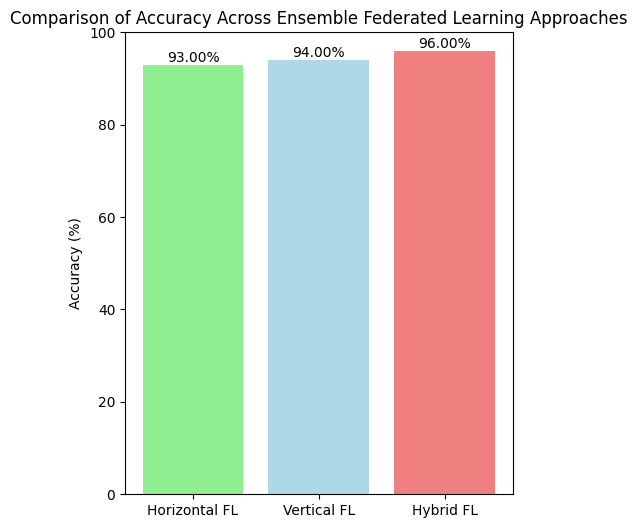

In [ ]:
import matplotlib.pyplot as plt

# Accuracy values from the three approaches (in percentages)
accuracy_horizontal = 93.00
accuracy_vertical = 94.00
accuracy_hybrid = 96.00

# Performance metrics for bar plot
metrics = ['Horizontal FL', 'Vertical FL', 'Hybrid FL']
scores = [accuracy_horizontal, accuracy_vertical, accuracy_hybrid]

# Plotting the combined bar plot
plt.figure(figsize=(5, 6))
bars = plt.bar(metrics, scores, color=['lightgreen', 'lightblue', 'lightcoral'])
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Accuracy Across Ensemble Federated Learning Approaches')

# Adding the accuracy values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.show()


**Final comparison**

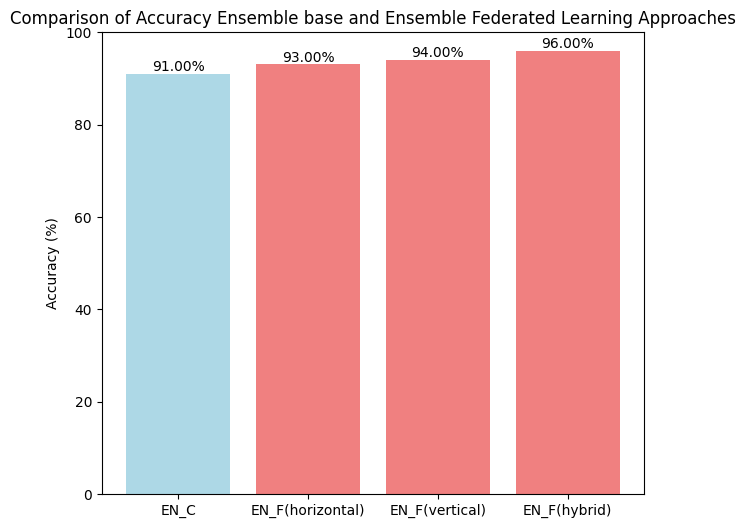

In [ ]:
import matplotlib.pyplot as plt

# Accuracy values from the three approaches (in percentages)
accuracy_base = 91.00
accuracy_horizontal = 93.00
accuracy_vertical = 94.00
accuracy_hybrid = 96.00

# Performance metrics for bar plot
metrics = ['EN_C','EN_F(horizontal)', 'EN_F(vertical)', 'EN_F(hybrid)']
scores = [accuracy_base, accuracy_horizontal, accuracy_vertical, accuracy_hybrid]

# Plotting the combined bar plot
plt.figure(figsize=(7, 6))
bars = plt.bar(metrics, scores, color=['lightblue','lightcoral', 'lightcoral', 'lightcoral'])
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Accuracy Ensemble base and Ensemble Federated Learning Approaches')

# Adding the accuracy values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

plt.show()


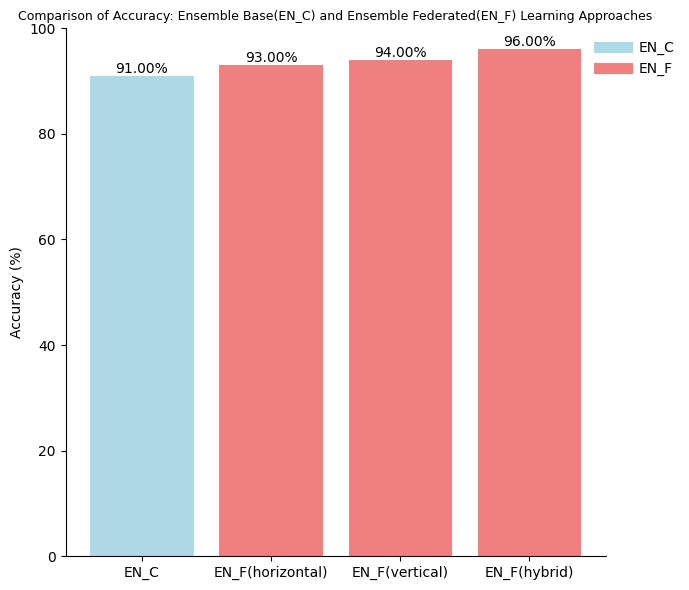

In [ ]:
import matplotlib.pyplot as plt

# Accuracy values from the three approaches (in percentages)
accuracy_base = 91.00
accuracy_horizontal = 93.00
accuracy_vertical = 94.00
accuracy_hybrid = 96.00

# Performance metrics for bar plot
metrics = ['EN_C', 'EN_F(horizontal)', 'EN_F(vertical)', 'EN_F(hybrid)']
scores = [accuracy_base, accuracy_horizontal, accuracy_vertical, accuracy_hybrid]

# Plotting the combined bar plot
plt.figure(figsize=(7, 6))
colors = ['lightblue', 'lightcoral', 'lightcoral', 'lightcoral']
bars = plt.bar(metrics, scores, color=colors)
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Accuracy: Ensemble Base(EN_C) and Ensemble Federated(EN_F) Learning Approaches', fontsize=9)

# Adding the accuracy values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

# Adding a legend outside the plot area
custom_legend = [
    plt.Line2D([0], [0], color='lightblue', lw=8, label='EN_C'),
    plt.Line2D([0], [0], color='lightcoral', lw=8, label='EN_F')
]
plt.legend(
    handles=custom_legend,
    loc='upper right',
    bbox_to_anchor=(1.15, 1),  # Positioned outside the plot area
    fontsize=10,
    title_fontsize=11,
    frameon=False
)

# Removing the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

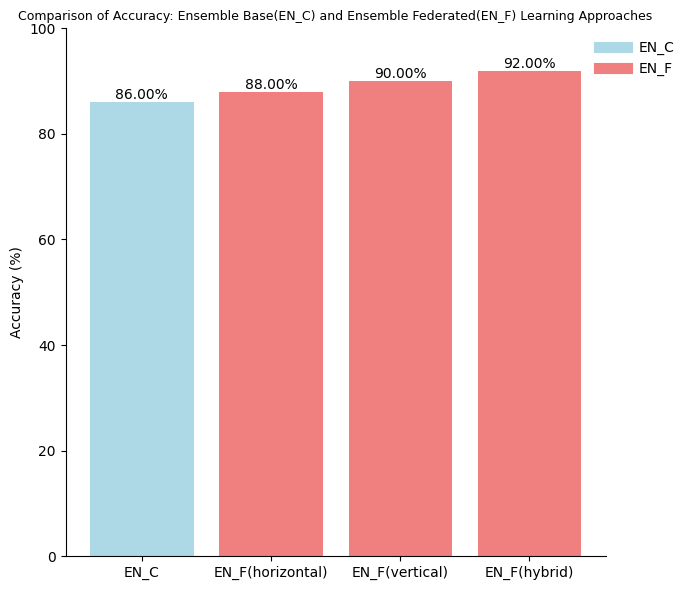

In [ ]:
import matplotlib.pyplot as plt

# Accuracy values from the three approaches (in percentages)
accuracy_base = 86.00
accuracy_horizontal = 88.00
accuracy_vertical = 90.00
accuracy_hybrid = 92.00

# Performance metrics for bar plot
metrics = ['EN_C', 'EN_F(horizontal)', 'EN_F(vertical)', 'EN_F(hybrid)']
scores = [accuracy_base, accuracy_horizontal, accuracy_vertical, accuracy_hybrid]

# Plotting the combined bar plot
plt.figure(figsize=(7, 6))
colors = ['lightblue', 'lightcoral', 'lightcoral', 'lightcoral']
bars = plt.bar(metrics, scores, color=colors)
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Accuracy: Ensemble Base(EN_C) and Ensemble Federated(EN_F) Learning Approaches', fontsize=9)

# Adding the accuracy values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

# Adding a legend outside the plot area
custom_legend = [
    plt.Line2D([0], [0], color='lightblue', lw=8, label='EN_C'),
    plt.Line2D([0], [0], color='lightcoral', lw=8, label='EN_F')
]
plt.legend(
    handles=custom_legend,
    loc='upper right',
    bbox_to_anchor=(1.15, 1),  # Positioned outside the plot area
    fontsize=10,
    title_fontsize=11,
    frameon=False
)

# Removing the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()  # Adjust layout for better spacing
plt.show()